# Walkthrough - Attention and a Tiny Transformer

We will:
1. Implement **scaled dot-product attention** from scratch and check it against PyTorch.
2. Visualize attention weights.
3. Build a **tiny causal transformer** and train it on a toy task: copying a sequence
   *after* a delimiter (impossible without attending far back).

Companion lesson: Lesson 05 - Attention and Transformers.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Part 1 - Scaled dot-product attention from scratch

$$\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [2]:
def attention(q, k, v, causal=False):
    """q, k, v: (..., seq, d_k). Returns (output, attention weights)."""
    d_k = q.shape[-1]
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)  # (..., seq, seq)
    if causal:
        n = scores.shape[-1]
        mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)  # future positions
        scores = scores.masked_fill(mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ v, weights


# sanity check against PyTorch's implementation
q, k, v = torch.randn(3, 8, 16), torch.randn(3, 8, 16), torch.randn(3, 8, 16)
ours, _ = attention(q, k, v, causal=True)
ref = F.scaled_dot_product_attention(q, k, v, is_causal=True)
print("max abs difference vs torch:", (ours - ref).abs().max().item())

max abs difference vs torch: 0.0


### Why the $\sqrt{d_k}$? Watch the softmax saturate without it.

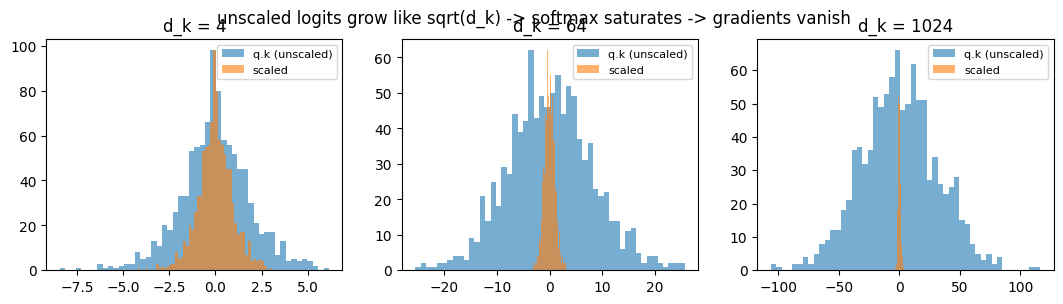

In [3]:
d_ks = [4, 64, 1024]
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, d_k in zip(axes, d_ks):
    q, k = torch.randn(1000, d_k), torch.randn(1000, d_k)
    raw = (q * k).sum(-1)
    ax.hist(raw.numpy(), bins=50, alpha=0.6, label="q.k (unscaled)")
    ax.hist((raw / math.sqrt(d_k)).numpy(), bins=50, alpha=0.6, label="scaled")
    ax.set_title(f"d_k = {d_k}")
    ax.legend(fontsize=8)
plt.suptitle("unscaled logits grow like sqrt(d_k) -> softmax saturates -> gradients vanish")
plt.show()

## Part 2 - The task: copy after a delimiter

Input:  `a b c d | . . . .` -> the model must output `a b c d` at the positions after `|`.
Position $i$ after the delimiter needs the token at position $i - L - 1$: pure long-range
attention, no local pattern helps.

In [4]:
VOCAB = 12  # tokens 0..9 are symbols, 10 = delimiter, 11 = pad/dummy
L = 8       # length of the sequence to copy


def make_batch(batch_size):
    symbols = torch.randint(0, 10, (batch_size, L))
    delim = torch.full((batch_size, 1), 10)
    dummies = torch.full((batch_size, L), 11)
    x = torch.cat([symbols, delim, dummies], dim=1)     # (B, 2L+1)
    y = torch.full_like(x, -100)                        # -100 = ignored by the loss
    y[:, L + 1:] = symbols                              # predict the copy after '|'
    return x.to(device), y.to(device)


x, y = make_batch(2)
print("input :", x[0].tolist())
print("target:", y[0].tolist())

input : [4, 3, 2, 0, 6, 2, 6, 7, 10, 11, 11, 11, 11, 11, 11, 11, 11]
target: [-100, -100, -100, -100, -100, -100, -100, -100, -100, 4, 3, 2, 0, 6, 2, 6, 7]


## Part 3 - A tiny transformer (pre-norm blocks, learned positions)

In [5]:
class Block(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x, mask):
        h = self.ln1(x)
        a, w = self.attn(h, h, h, attn_mask=mask, need_weights=True, average_attn_weights=True)
        x = x + a          # residual connection around attention
        x = x + self.mlp(self.ln2(x))  # residual around the position-wise MLP
        return x, w


class TinyTransformer(nn.Module):
    def __init__(self, vocab=VOCAB, d=64, heads=4, n_layers=2, max_len=64):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(max_len, d)   # learned positional embeddings
        self.blocks = nn.ModuleList([Block(d, heads) for _ in range(n_layers)])
        self.head = nn.Linear(d, vocab)

    def forward(self, x):
        n = x.shape[1]
        causal = torch.triu(torch.ones(n, n, dtype=torch.bool, device=x.device), 1)
        h = self.tok(x) + self.pos(torch.arange(n, device=x.device))
        attn_maps = []
        for block in self.blocks:
            h, w = block(h, causal)
            attn_maps.append(w)
        return self.head(h), attn_maps


model = TinyTransformer().to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 105,612


  0%|          | 0/2000 [00:00<?, ?it/s]

loss 2.621:   0%|          | 0/2000 [00:00<?, ?it/s]

loss 2.621:   0%|          | 1/2000 [00:00<05:56,  5.61it/s]

loss 2.621:   0%|          | 9/2000 [00:00<00:52, 37.57it/s]

loss 2.621:   1%|          | 17/2000 [00:00<00:37, 52.43it/s]

...

loss 0.000:  98%|█████████▊| 1969/2000 [00:26<00:00, 74.91it/s]

loss 0.000:  99%|█████████▉| 1977/2000 [00:26<00:00, 74.87it/s]

loss 0.000:  99%|█████████▉| 1985/2000 [00:26<00:00, 74.77it/s]

loss 0.000: 100%|█████████▉| 1993/2000 [00:26<00:00, 74.64it/s]

loss 0.000: 100%|██████████| 2000/2000 [00:26<00:00, 74.39it/s]

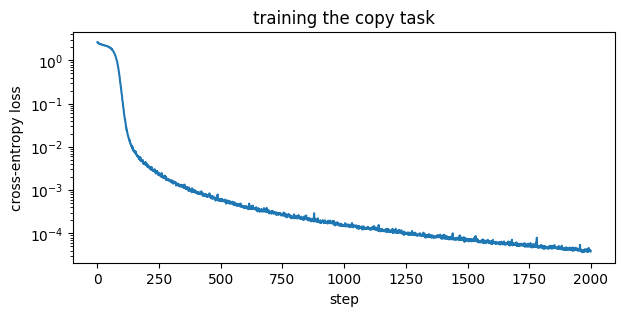

In [6]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
losses = []
pbar = tqdm(range(2000))
for step in pbar:
    x, y = make_batch(64)
    logits, _ = model(x)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1), ignore_index=-100)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 200 == 0:
        pbar.set_description(f"loss {loss.item():.3f}")

plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.yscale("log")
plt.title("training the copy task")
plt.show()

In [7]:
x, y = make_batch(512)
with torch.no_grad():
    logits, attn_maps = model(x)
pred = logits.argmax(-1)
mask = y != -100
acc = (pred[mask] == y[mask]).float().mean().item()
print(f"copy accuracy on fresh data: {acc:.4f}")

copy accuracy on fresh data: 1.0000


## Part 4 - Look at what the model attends to

Rows = query positions, columns = key positions. The output positions (after the
delimiter, row $L+1+i$) should attend to their source symbol (column $i$): a bright
shifted diagonal in the bottom-left block.

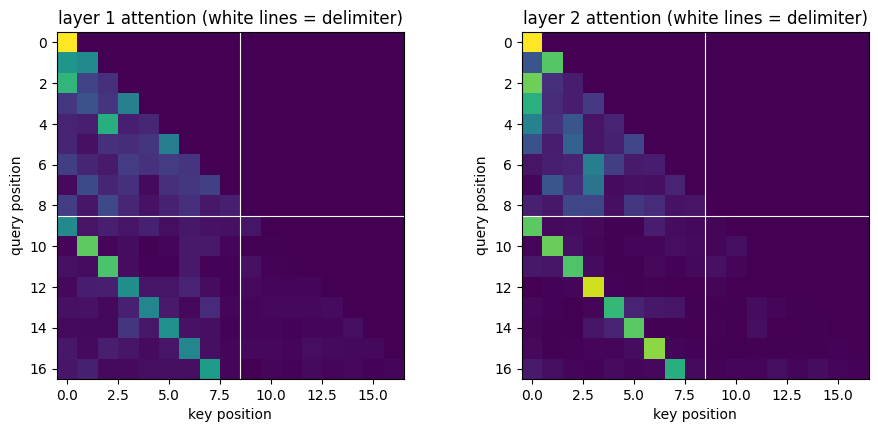

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (l, w) in zip(axes, enumerate(attn_maps)):
    ax.imshow(w[0].cpu(), cmap="viridis")
    ax.axhline(L + 0.5, color="w", lw=0.8); ax.axvline(L + 0.5, color="w", lw=0.8)
    ax.set_title(f"layer {l + 1} attention (white lines = delimiter)")
    ax.set_xlabel("key position"); ax.set_ylabel("query position")
plt.show()

### TODO exercises

1. Remove the positional embedding (`self.pos`) and retrain. The task should become
   unlearnable - explain why using the permutation-equivariance argument from the lesson.
2. Train an LSTM (`nn.LSTM`, similar parameter count) on the same task. Compare steps-to-solve
   for L=8 and L=32 - this is the "path length 1 vs path length t" claim made concrete.
3. Increase L until the model fails to learn within 2000 steps. What breaks first?
4. Replace learned positions with the sinusoidal encoding from the lesson and compare.